# Saliency Maps

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients, run_forecast_with_integrated_gradients
from pkg.gcs_utils.client import download_file

## Run Forecast

In [3]:
from pkg.forecast.run_forecast import get_model_checkpoint

# 1) get checkpoint just for task_config
ckpt, _, _ = get_model_checkpoint("graphcast_small")

# 2) load example batch
input = xr.open_dataset(
    "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
).load()

# 3) load climatology
climatology = xr.open_dataset(
    "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"
)

print("Input variables:", list(input.keys()))
print("Climatology variables:", list(climatology.variables))

print("Input levels:", input['level'].values)
print("Climatology levels:", climatology['level'].values)
print("Input time:", input['time'].values)
print("Climatology time:", climatology['time'].values)

def ensure_time_features(ds):
    # Add missing time/seasonal/forcing variables with correct dims
    time = ds['time']
    batch_dim = ds['batch'].shape[0] if 'batch' in ds.dims else 1
    time_dim = time.shape[0]
    lat_dim = ds['lat'].shape[0]
    lon_dim = ds['lon'].shape[0]

    # Add year_progress_sin/cos
    if 'year_progress_sin' not in ds:
        ds['year_progress_sin'] = (('batch', 'time'), np.zeros((batch_dim, time_dim)))
    if 'year_progress_cos' not in ds:
        ds['year_progress_cos'] = (('batch', 'time'), np.ones((batch_dim, time_dim)))
    # Add day_progress_sin/cos
    if 'day_progress_sin' not in ds:
        ds['day_progress_sin'] = (('batch', 'time', 'lon'), np.zeros((batch_dim, time_dim, lon_dim)))
    if 'day_progress_cos' not in ds:
        ds['day_progress_cos'] = (('batch', 'time', 'lon'), np.ones((batch_dim, time_dim, lon_dim)))
    # Add toa_incident_solar_radiation
    if 'toa_incident_solar_radiation' not in ds:
        ds['toa_incident_solar_radiation'] = (('batch', 'time', 'lat', 'lon'), np.zeros((batch_dim, time_dim, lat_dim, lon_dim)))
    return ds

input = ensure_time_features(input)

def align_climatology_to_input(climatology, input):
    # Align all coords present in both
    for coord in ['level', 'time', 'lat', 'lon']:
        if coord in climatology and coord in input:
            climatology = climatology.assign_coords({coord: input[coord].values})
    return climatology

climatology = align_climatology_to_input(climatology, input)

# 4) run (we pass the xr.Dataset directly — the function will convert it)
run_forecast_with_integrated_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    baseline=climatology,   # OK to hand it the Dataset
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    m_steps=20,
    upload_to_gcs=False,
)



📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz
Input variables: ['temperature', 'u_component_of_wind', 'v_component_of_wind', 'geopotential', 'vertical_velocity', 'specific_humidity', '2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure', 'total_precipitation_6hr', 'geopotential_at_surface', 'land_sea_mask']
Climatology variables: ['temperature', 'u_component_of_wind', 'v_component_of_wind', 'geopotential', 'specific_humidity', 'vertical_velocity', '2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure', 'total_precipitation_6hr', 'number', 'level', 'lat', 'time', 'lon']
Input levels: [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   50.]
Climatology levels: [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   50.]
Input time: ['2022-02-18T10:00

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']


Inputs keys: ['2m_temperature', 'mean_sea_level_pressure', '10m_v_component_of_wind', '10m_u_component_of_wind', 'total_precipitation_6hr', 'temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'specific_humidity', 'toa_incident_solar_radiation', 'year_progress_sin', 'year_progress_cos', 'day_progress_sin', 'day_progress_cos', 'geopotential_at_surface', 'land_sea_mask']
Climatology keys: ['temperature', 'u_component_of_wind', 'v_component_of_wind', 'geopotential', 'specific_humidity', 'vertical_velocity', '2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure', 'total_precipitation_6hr', 'number', 'level', 'time', 'lat', 'lon']
>>> [DEBUG] baseline type after conversion: <class 'dict'>
2m_temperature: input shape (1, 2, 181, 360), baseline shape (1, 2, 181, 360)
mean_sea_level_pressure: input shape (1, 2, 181, 360), baseline shape (1, 2, 181, 360)
10m_v_component_of_wind: input shape (1, 2, 181, 360),

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = inputs.dims['time']


✅ Saliency saved to: data/predictions/zeynep_wind_grad_intgrad.nc
✅ Integrated gradients saved to data/predictions/zeynep_wind_grad_intgrad.nc


In [ ]:
# Run on server

import os

os.makedirs("data/data_for_climatology", exist_ok=True)
os.makedirs("data/prediction_zeynep_22/input_data", exist_ok=True)

# Get files from bucket climatology and input data
download_file(
    blob_path="data/data_for_climatology/era5_1979-2015_0218_climatology.nc",
    local_path="data/data_for_climatology/era5_1979-2015_0218_climatology.nc"
)

download_file(
    blob_path="data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    local_path="data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
)

climatology = xr.open_dataset("data/data_for_climatology/era5_1979-2015_0218_climatology.nc")
input_data = xr.open_dataset("data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc")

run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input_data,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=True,
    m_steps=1
)

## Visualize Results

In [5]:
saliency_path = "data/predictions/zeynep_wind_grad_saliency.nc"
saliency_path_grad_x_input = "data/predictions/zeynep_wind_grad_grad_x_input.nc"

saliency_path_integrated_gradients = "data/predictions/zeynep_wind_grad_intgrad.nc"

input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"  

sal_ds = xr.open_dataset(saliency_path)
sal_ds_grad_x_input = xr.open_dataset(saliency_path_grad_x_input)
sal_ds_integrated_gradients = xr.open_dataset(saliency_path_integrated_gradients)

input_ds = xr.open_dataset(input_path)


In [6]:
# Compute mean(|saliency|) for each feature
scores = []
for var in sal_ds_integrated_gradients.data_vars:
    da = sal_ds_integrated_gradients[var]
    # use built-in abs to get a DataArray of absolute values
    mean_abs = float(abs(da).mean().item())   # .item() to get a Python float
    scores.append((var, mean_abs))

# Build a DataFrame and sort descending
df = pd.DataFrame(scores, columns=["feature", "mean_abs_saliency"])
df = df.sort_values("mean_abs_saliency", ascending=False).reset_index(drop=True)

print(df)


                                  feature  mean_abs_saliency
0              year_progress_sin_saliency       1.150203e-03
1              year_progress_cos_saliency       1.062031e-03
2              specific_humidity_saliency       3.579781e-04
3                   geopotential_saliency       2.979979e-04
4        10m_u_component_of_wind_saliency       4.812617e-05
5        10m_v_component_of_wind_saliency       1.973405e-05
6               day_progress_cos_saliency       1.429920e-05
7               day_progress_sin_saliency       1.429779e-05
8        mean_sea_level_pressure_saliency       7.899577e-06
9                    temperature_saliency       6.703213e-06
10                 land_sea_mask_saliency       5.512136e-06
11       geopotential_at_surface_saliency       1.867270e-06
12           u_component_of_wind_saliency       1.358952e-06
13           v_component_of_wind_saliency       9.692358e-07
14                2m_temperature_saliency       8.628529e-07
15             vertical_

In [7]:
def plot_atmospheric_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    target_level: float,
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Plot a single‐level atmospheric saliency map over Europe.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'level', 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    target_level : float
        The pressure level (hPa) to slice, e.g. 500.
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    da = sal_ds[f"{varname}_saliency"]
    # find integer index of the nearest level in input_ds
    levels = input_ds["level"].values
    lvl_idx = int(np.argmin(np.abs(levels - target_level)))

    # slice out the 2D field
    da2d = da.isel(batch=batch_index, time=time_index, level=lvl_idx)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )

    # build the figure with Cartopy
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency @ "
            f"{levels[lvl_idx]:.0f} hPa → 10 m Wind"
        )
    ax.set_title(title + f" (t={time_index}, batch={batch_index})")
    plt.tight_layout()
    plt.show()


In [8]:
def plot_aggregated_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    method: str = "mean",
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Aggregate saliency over all pressure levels and plot the 2D map.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    method : str
        Aggregation along the level axis: "mean" or "sum".
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    # pull the saliency
    da = sal_ds[f"{varname}_saliency"]
    
    # aggregate over levels
    if method == "mean":
        da2d = da.mean(dim="level")
    elif method == "sum":
        da2d = da.sum(dim="level")
    else:
        raise ValueError("method must be 'mean' or 'sum'")
    
    # select the desired time & batch slice
    da2d = da2d.isel(batch=batch_index, time=time_index)
    
    # reattach real coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )
    
    # build the map
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    vmax = np.abs(da2d).max()
    pcm = da2d.plot.pcolormesh(
        ax=ax, x="lon", y="lat",
        cmap=cmap, vmin=-vmax, vmax=vmax,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    agg_label = "Mean" if method=="mean" else "Sum"
    cbar.set_label(f"{agg_label} ∂Wind/∂{varname.replace('_',' ').title()}")
    
    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency ({agg_label} over levels)"
        )
    ax.set_title(f"{title} – t={time_index}, batch={batch_index}")
    plt.tight_layout()
    plt.show()


In [9]:
def plot_surface_saliency(
    ds_sal: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    time_index: int = -1,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r"
):
    """
    Plot a surface‐only saliency field (no level dim) on a European map.
    
    Parameters
    ----------
    ds_sal : xr.Dataset
      Dataset containing `<varname>_saliency` with dims (batch, time, lat, lon).
    input_ds : xr.Dataset
      Original input, used for lat/lon coords.
    varname : str
      The base variable name, e.g. "2m_temperature" or "mean_sea_level_pressure".
    extent : list
      [lon_min, lon_max, lat_min, lat_max] for map zoom.
    cmap : str
      A matplotlib colormap name.
    """
    da = ds_sal[f"{varname}_saliency"]  # dims: (batch, time, lat, lon)

    # pick batch=0, last time
    da2d = da.isel(batch=0, time=time_index)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(lat=input_ds["lat"], lon=input_ds["lon"])

    # plot
    fig, ax = plt.subplots(
        figsize=(8, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    ax.set_title(f"{varname.replace('_',' ').title()} Saliency → 10 m Wind (22:00 UTC)")
    plt.tight_layout()
    plt.show()



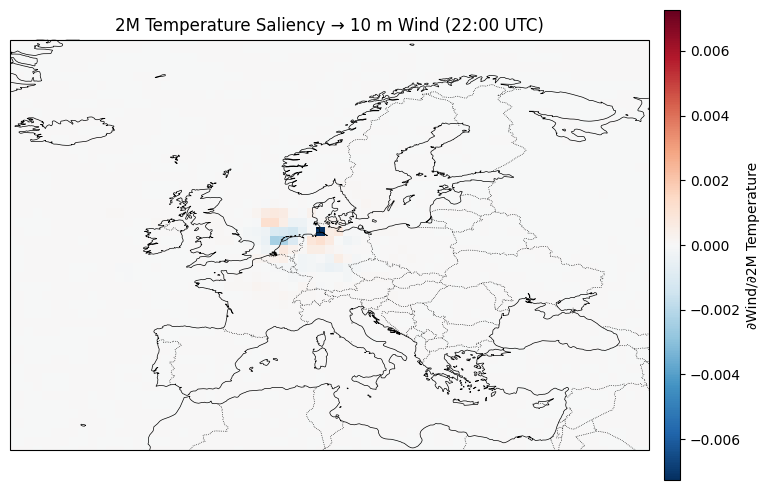

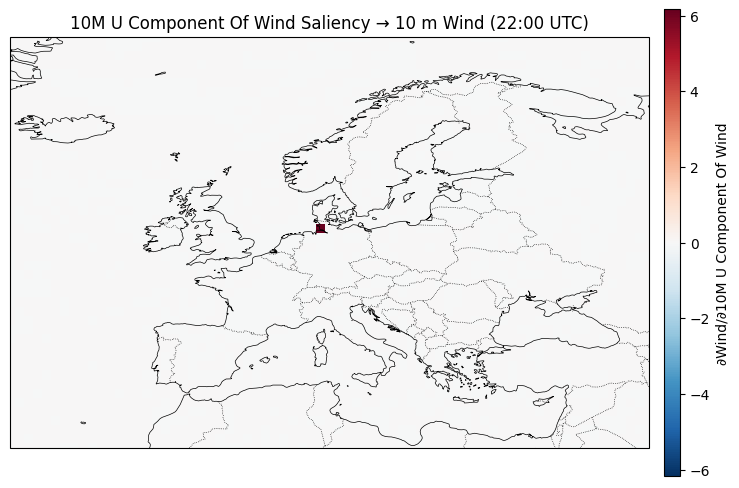

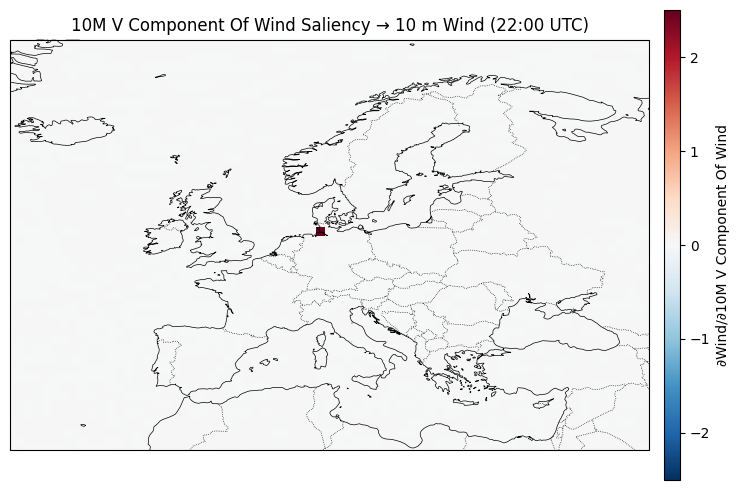

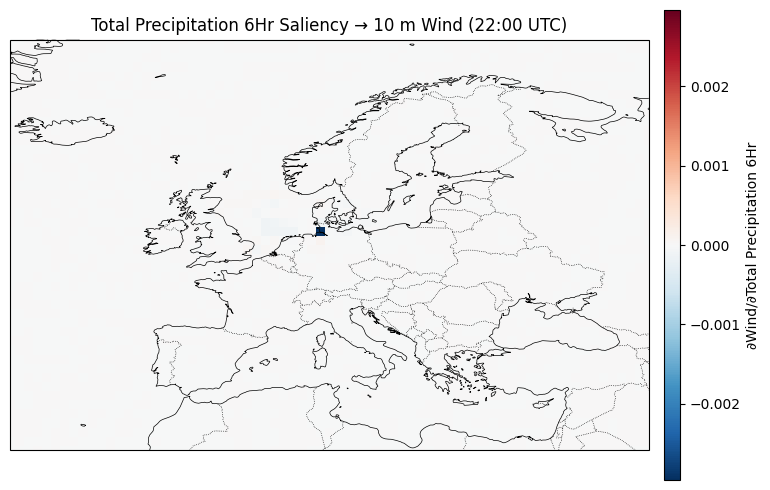

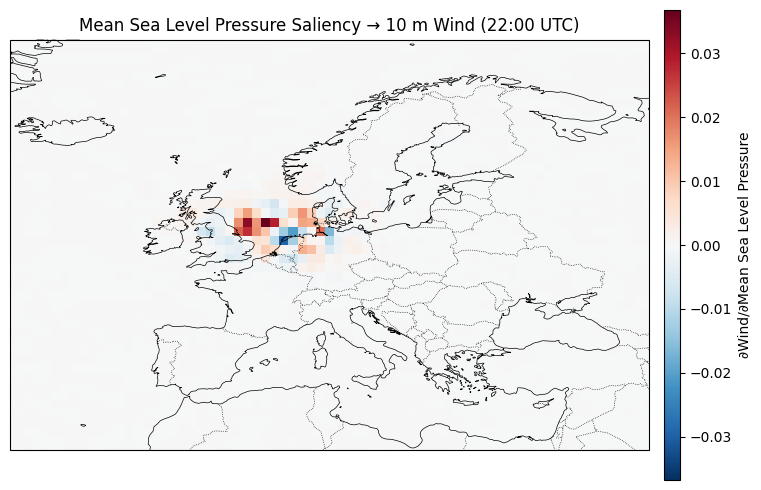

In [10]:
for surf_var in [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation_6hr",
    "mean_sea_level_pressure"
]:
    plot_surface_saliency(sal_ds_integrated_gradients, input_ds, surf_var, time_index=-1)

Positive values mean increase of input values would also lead to increase of output

Negative values mean that a increase of the input value would lead to a decrease of the output

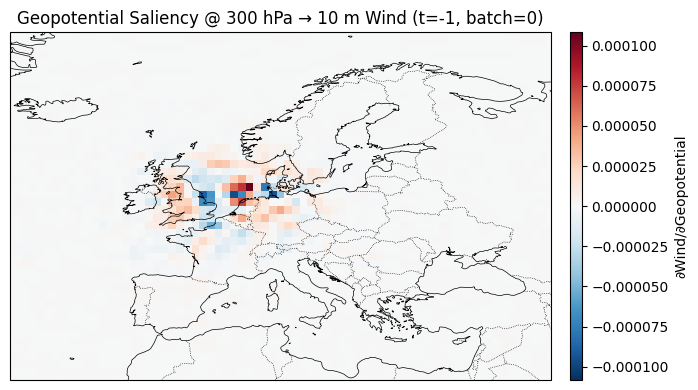

In [16]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

plot_atmospheric_saliency(
    sal_ds=sal_ds,
    input_ds=input_ds,
    varname="geopotential",
    target_level=300.0,
    time_index=-1,
    batch_index=0,
    extent=[-25, 45, 30, 75],
    cmap="RdBu_r"
)

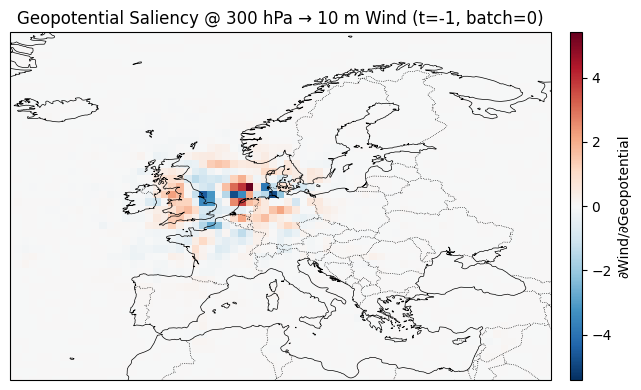

In [17]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

plot_atmospheric_saliency(
    sal_ds=sal_ds_grad_x_input,
    input_ds=input_ds,
    varname="geopotential",
    target_level=300.0,
    time_index=-1,
    batch_index=0,
    extent=[-25, 45, 30, 75],
    cmap="RdBu_r"
)

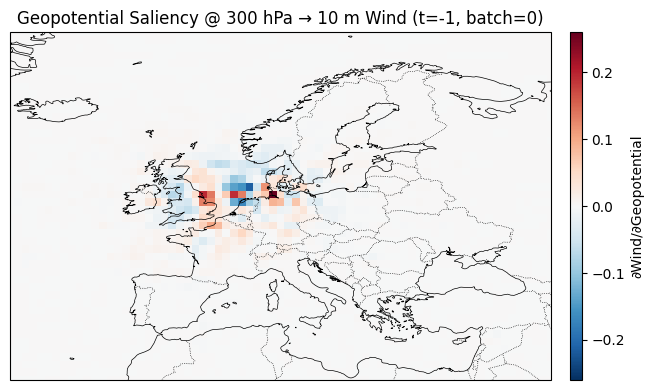

In [11]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

plot_atmospheric_saliency(
    sal_ds=sal_ds_integrated_gradients,
    input_ds=input_ds,
    varname="geopotential",
    target_level=300.0,
    time_index=-1,
    batch_index=0,
    extent=[-25, 45, 30, 75],
    cmap="RdBu_r"
)